## Phase 1: Loading and inspecting Data

In [1]:
import pandas as pd
import numpy as np

df= pd.read_csv('google_playstore_2026.csv')

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   App               11500 non-null  str    
 1   Category          11500 non-null  str    
 2   Rating            6123 non-null   float64
 3   Reviews           11500 non-null  int64  
 4   Size              11500 non-null  str    
 5   Installs          11500 non-null  str    
 6   Type              11500 non-null  str    
 7   Price             11500 non-null  float64
 8   Content Rating    11500 non-null  str    
 9   Genres            11500 non-null  str    
 10  Last Updated      11500 non-null  str    
 11  Current Ver       11500 non-null  str    
 12  Android Ver       11500 non-null  str    
 13  In-App Purchases  11500 non-null  str    
 14  Ad Supported      11500 non-null  str    
dtypes: float64(2), int64(1), str(12)
memory usage: 1.3 MB


### Observations from `.info()`
- 15 columns total: 12 object (string), 2 float, 1 int
- `Installs`is  stored as strings even though it is  numeric — will need cleaning
- `Rating` has missing values (fewer non-null entries than total rows)
- `Last Updated` is a string, not datetime — will need conversion

In [3]:
df.head(60)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,In-App Purchases,Ad Supported
0,Strike Plus,FAMILY,4.6,12460594,Varies with device,"500,000,000+",Free,0.00,Teen,Family,"January 15, 2026",Varies with device,8.0 and up,Yes,Yes
1,Tracker AI,EDUCATION,3.4,11487705,Varies with device,"500,000,000+",Free,0.00,Everyone,Education,"October 22, 2025",Varies with device,11.0 and up,Yes,Yes
2,Scanner,FAMILY,3.5,10503932,Varies with device,"500,000,000+",Paid,0.99,Everyone,Family,"November 08, 2024",Varies with device,10.0 and up,No,No
3,Connect 3D,ART_AND_DESIGN,4.7,4818860,221.6M,"100,000,000+",Free,0.00,Everyone,Art And Design,"October 07, 2025",6.8.21,10.0 and up,No,Yes
4,VPN,PRODUCTIVITY,3.5,3562800,122.9M,"100,000,000+",Free,0.00,Everyone,Productivity,"June 29, 2026",5.5.11,12.0 and up,Yes,Yes
5,Planner,ART_AND_DESIGN,3.9,2432119,187.4M,"100,000,000+",Free,0.00,Everyone,Art And Design,"June 28, 2026",12.2.16,8.0 and up,Yes,Yes
6,Pay 3D,ARTIFICIAL_INTELLIGENCE,5.0,1473707,15.6M,"100,000,000+",Free,0.00,Everyone,Artificial Intelligence;Creativity,"March 19, 2026",5.18.66,9.0 and up,No,Yes
7,Browser Now,MEDICAL,4.2,1428040,80.1M,"100,000,000+",Free,0.00,Teen,Medical,"February 01, 2026",3.1.10,10.0 and up,No,No
8,Player Max,TOOLS,4.0,677625,134.0M,"100,000,000+",Free,0.00,Everyone 10+,Tools,"September 06, 2025",5.17.88,9.0 and up,No,Yes
9,Quick Pay,SOCIAL,3.8,2252646,127.5M,"50,000,000+",Free,0.00,Mature 17+,Social,"April 14, 2025",7.3.81,Varies with device,Yes,Yes


- we can see what is going on with `Installs` column with checking first 5 rows with .head()
- it is labeled as str because it contains signs as '+' and ','

In [4]:
df.shape

(11500, 15)

- just to keep in  mind how many rows we have by .shape().

# Phase 2: Cleaning Data

### List of thing that we have to deal with in this phase
- `Installs` column data is stored as str we have to strip `+` and `,` and repalce with a generalized value
- `Rating` column contains less non-null than other columns so we have to deal with this thing.
-  In `Size` there are values like `varies with device` ,so for this we have to either replace with null or replace them with a generalized value
-  `Last updated` column contains date but are in str format we have to change that to datetime format so we can deduce better results from that
-  in `Android ver` column we have to remove that `_ and up` with a numeric value
-  last thing that we will be doing in this phase is for `In-app-purchases` and `AD-supported` column is make them a boolean value

In [5]:
#1.
df['Installs'] = df['Installs'].str.strip('+')
df['Installs'] = df['Installs'].str.replace(',','')
df['Installs'] = df['Installs'].astype(float)

In [6]:
#2. i am replacing null value with median and to be more accurate median acc to genre
df['Rating'] = df['Rating'].fillna(df.groupby('Category')['Rating'].transform('median'))

In [7]:
#3 for this i am also changing Varies with device to median acc to genre
filt = df['Size'] == 'Varies with device'
df.loc[filt, 'Size'] = np.nan
df['Size'] = df['Size'].str.replace('M', '', regex=False)
df['Size'] = df['Size'].astype(float)
df['Size'] = df['Size'].fillna(df.groupby('Category')['Size'].transform('median'))



In [8]:
#4
df['Last Updated'] = pd.to_datetime(df['Last Updated'], format='%B %d, %Y')

In [9]:
#5
df['Android Ver'] = df['Android Ver'].str.replace(' and up','')
filt = df['Android Ver'] == 'Varies with device'
df.loc[filt,'Android Ver'] = np.nan
df['Android Ver'] = df['Android Ver'].astype(float)
df['Android Ver'] = df['Android Ver'].fillna(df.groupby('Category')['Android Ver'].transform('median'))

In [10]:
#6
df['In-App Purchases'] = df['In-App Purchases'].map({'Yes': True, 'No': False})
df['Ad Supported'] = df['Ad Supported'].map({'Yes': True, 'No': False})

In [11]:
# final df
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,In-App Purchases,Ad Supported
0,Strike Plus,FAMILY,4.6,12460594,77.6,500000000.0,Free,0.00,Teen,Family,2026-01-15,Varies with device,8.0,True,True
1,Tracker AI,EDUCATION,3.4,11487705,81.3,500000000.0,Free,0.00,Everyone,Education,2025-10-22,Varies with device,11.0,True,True
2,Scanner,FAMILY,3.5,10503932,77.6,500000000.0,Paid,0.99,Everyone,Family,2024-11-08,Varies with device,10.0,False,False
3,Connect 3D,ART_AND_DESIGN,4.7,4818860,221.6,100000000.0,Free,0.00,Everyone,Art And Design,2025-10-07,6.8.21,10.0,False,True
4,VPN,PRODUCTIVITY,3.5,3562800,122.9,100000000.0,Free,0.00,Everyone,Productivity,2026-06-29,5.5.11,12.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,Epic Learn Plus,PRODUCTIVITY,4.0,0,74.3,10.0,Free,0.00,Everyone,Productivity,2024-08-16,8.8.45,11.0,True,True
11496,Scanner Pro,PHOTOGRAPHY,3.9,0,34.8,10.0,Free,0.00,Everyone,Photography,2024-09-10,7.9.59,11.0,True,True
11497,Dash 2023,WEATHER,4.2,0,34.4,10.0,Free,0.00,Everyone,Weather,2025-11-13,2.3.74,9.0,True,True
11498,Pro Strike,BOOKS_AND_REFERENCE,3.8,0,81.1,10.0,Free,0.00,Everyone,Books And Reference,2025-10-30,2.7.72,12.0,True,False


## Phase 2 Conclusion: Data Cleaning

Now that our data is cleaned, we can analyze it more efficiently. Key changes made:

- Converted string columns (`Installs`, `Price`, `Size`) to numeric data types, 
  so mathematical operations (mean, median, sum, etc.) can be performed on them
- Filled missing values with category-level medians rather than a single fixed value, 
  so our conclusions stay accurate and account for variation across categories
- Converted `Last Updated` from string to actual datetime format, 
  so we can perform date-based operations (sorting, filtering by year, calculating recency) 
  instead of treating dates as plain text

# ----------------------------------------------------------------

# Phase 3: Analysis Questions

- In this phase of our project we will be answering analysis question related to our dataset
- while answering the question i will be keeping a structure to maintain good readibility
  ### structure:-
- question
- code
- brief explanation

### Q1. which category has the highest rating

In [12]:
df.groupby('Category')['Rating'].mean().idxmax()

'ARTIFICIAL_INTELLIGENCE'

`Artificial_intelligence` category has highest average rating
- to find this i used `groupby('Category')` method then performed .`mean()` func on groups and found maximum by `idxmax()` function 

### Q2. Which category has the most apps overall??

In [13]:
df.groupby('Category').size().idxmax()

'GAME'

`Game` Category has the most apps overall.
- again i used the same group method as previous question but instead of `.mean()` i used `.size()` method to find number of apps per category 

### Q3. Which category has the most total installs?

In [14]:
df.groupby('Category')['Installs'].sum().idxmax()

'FAMILY'

`Family` Category has the most Installs overall.

### Q4. Is there a correlation between number of reviews and rating?

In [15]:
df[['Reviews','Rating']].corr()

,Reviews,Rating
Reviews,1.000000,-0.003579
Rating,-0.003579,1.000000


- `df[['Reviews','Rating']].corr()` computes the Pearson correlation coefficient between 
  `Reviews` and `Rating`, which measures the strength and direction of a linear relationship 
  between them (ranges from -1 to +1). From the output, this value is approximately -0.0036, 
  which is essentially 0 — meaning there is no meaningful linear relationship between how 
  many reviews an app has and its rating.

- To understand this more intuitively, imagine plotting `Reviews` vs `Rating` as a scatter 
  plot and drawing a "best fit" straight line through the points. A correlation near 0 means 
  that line would come out essentially flat — knowing an app's review count tells us almost 
  nothing about what rating to expect.

- Now let's plot this relation using the `matplotlib` library to visually confirm it.

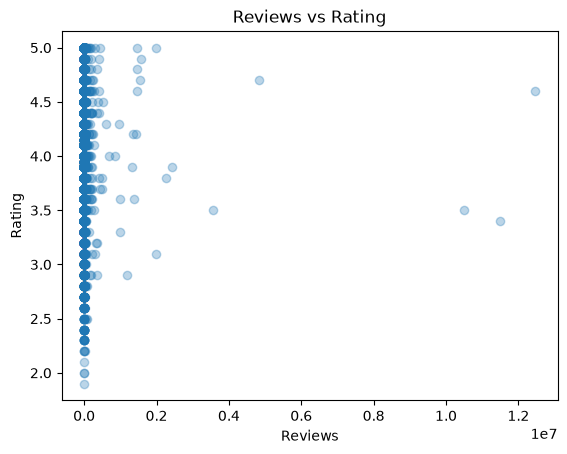

In [16]:
import matplotlib.pyplot as plt
plt.scatter(df['Reviews'], df['Rating'], alpha=0.3)
plt.xlabel('Reviews')
plt.ylabel('Rating')
plt.title('Reviews vs Rating')
plt.show()

we can see a cloud of points with no clear upward or downward tilt — visually confirming the ~0 correlation

### Q5.What are the top 10 most-installed apps overall

In [17]:
df.sort_values('Installs',ascending = False).head(10)['App']

0     Strike Plus
2         Scanner
1      Tracker AI
6          Pay 3D
7     Browser Now
8      Player Max
5         Planner
4             VPN
3      Connect 3D
18       Meta VPN
Name: App, dtype: str

- Top 10 Apps by number of installs can be seen in the output.
- I mainly did it by sorting the data frame by number of installs in an descending order

### Q6.What are the top 10 highest-rated apps with at least, say, 100,000 reviews ?

In [18]:
filt = df['Reviews'] >= 100000
df.loc[filt].sort_values('Rating',ascending = False).head(10)['App']

29     Pro Scanner 3D
83           Drive 3D
71       Chat Premium
6              Pay 3D
86         Quick Dash
41        Browser Hub
10        Chat Online
12             Health
100             Maker
33             Wallet
Name: App, dtype: str

- Top 10 Apps with top rating and reviews atleast 100,000 are listed in above output.
- for reviews part i used a filter to filter out apps and rest i did with sorting .

### Q7 What percentage of apps are Free vs Paid?

In [19]:
(df.groupby('Type').size()/df.shape[0])*100

Type
Free    95.886957
Paid     4.113043
dtype: float64

 As we can see that most of the apps are free .

### Q8. Do paid apps have a higher average rating than free apps?

In [20]:
filt = df['Price'] == 0
x= df
x.loc[~filt,'Price'] = 1
temp = x
temp.groupby('Price')['Rating'].mean()

Price
0.0    4.067308
1.0    4.048097
Name: Rating, dtype: float64

As we can see that free apps have slightly better average rating than paid apps ,So no paid apps doesn't have higher average rating than free apps.
- to get this data i used filtering->duplicating->changing `Price` column in only 2 values->groupby and mean

### Q9. What is the average price of paid apps, by category? (which category has the priciest apps?)

In [21]:
df.loc[~filt].groupby('Category')['Price'].mean()

Category
ARTIFICIAL_INTELLIGENCE    1.0
ART_AND_DESIGN             1.0
AUTO_AND_VEHICLES          1.0
BEAUTY                     1.0
BOOKS_AND_REFERENCE        1.0
BUSINESS                   1.0
COMICS                     1.0
COMMUNICATION              1.0
DATING                     1.0
EDUCATION                  1.0
ENTERTAINMENT              1.0
EVENTS                     1.0
FAMILY                     1.0
FINANCE                    1.0
FOOD_AND_DRINK             1.0
GAME                       1.0
HEALTH_AND_FITNESS         1.0
HOUSE_AND_HOME             1.0
LIBRARIES_AND_DEMO         1.0
LIFESTYLE                  1.0
MAPS_AND_NAVIGATION        1.0
MEDICAL                    1.0
NEWS_AND_MAGAZINES         1.0
PARENTING                  1.0
PERSONALIZATION            1.0
PHOTOGRAPHY                1.0
PRODUCTIVITY               1.0
SHOPPING                   1.0
SOCIAL                     1.0
SPORTS                     1.0
TOOLS                      1.0
TRAVEL_AND_LOCAL           1.0

As we can see that every category in this list has same average price of 1$ so we can't name one partiv=cular app


### Q10. Do paid apps get fewer installs than free apps, on average?


In [22]:
df.groupby('Type')['Installs'].mean()

Type
Free    3.094138e+05
Paid    1.120478e+06
Name: Installs, dtype: float64

from the output we can see that yeah paid Apps get fewer Installs than Free Apps

### Q11. What percentage of apps are ad-supported?

In [23]:
(df['Ad Supported'].sum()/df.shape[0])*100

np.float64(77.09565217391304)

- from the output we can state that more than 3/4th part of all Apps are ad supported .and it is quite obvious that in one of the previous answers we found that major chunk of apps are free so ads might be the only source of developer to generate revenue

### Q12. Do ad-supported apps have lower ratings than non-ad-supported apps?

In [24]:
df.groupby('Ad Supported')['Rating'].median()

Ad Supported
False    4.0
True     4.0
Name: Rating, dtype: float64

from the median data we cant certainely say that if ad supported apps have lower rating comparatively or not as both have same median rating .

In [25]:
df.groupby('Ad Supported')['Rating'].mean()

Ad Supported
False    4.060706
True     4.068244
Name: Rating, dtype: float64

now we can conclude from the mean data that ,No the ad supported apps have slightly higher rating than non ad-supported apps.

### Q13. Are apps with in-app purchases more likely to also show ads?

In [26]:
pd.crosstab(df['In-App Purchases'], df['Ad Supported'])

Ad Supported,False,True
In-App Purchases,,
False,1148,2659
True,1486,6207


- From the crosstab method we can see that the number of Apps with ad support is higher than that of Apps wthat are not ad support 

### Q14. Which category has the highest proportion of apps with in-app purchases?


In [27]:
(df.groupby('Category')['In-App Purchases'].sum()/df.groupby('Category').size()).idxmax()

'VIDEO_PLAYERS'

- so to get to the answer of this question i used
      [grouping by category-> summing the in app purchases as it is boolean true will count as 1 and false         as 0->dividng by total size of category groups->getting the category with highestvalue of this ratio] 

### Q15. Is there a relationship between app size and rating? (bigger ≠ better?)


In [28]:
df[['Size','Rating']].corr()

,Size,Rating
Size,1.000000,0.207458
Rating,0.207458,1.000000


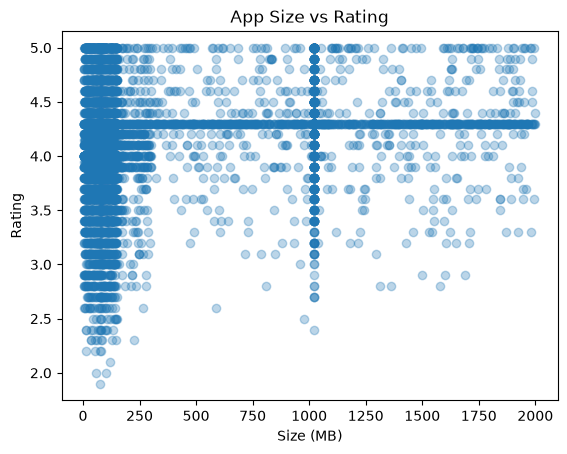

In [29]:
plt.scatter(df['Size'], df['Rating'], alpha=0.3)
plt.xlabel('Size (MB)')
plt.ylabel('Rating')
plt.title('App Size vs Rating')
plt.show()

**Approach:** Calculated the correlation between `Size` and `Rating`, then visualized 
with a scatter plot.

**Finding:** The correlation is approximately 0.20— a weak positive relationship. This 
suggests that larger apps have a slight tendency toward higher ratings, but the effect 
is small enough that size is not a strong predictor of rating on its own. "Bigger" is 
not strongly "better" here — there's just a mild tendency in that direction.
Code + plot:

### Q16. What's the distribution of apps across Content Rating (Everyone, Teen, Mature, etc.)?


In [30]:
df['Content Rating'].value_counts()

Content Rating
Everyone           7899
Teen               1683
Everyone 10+        940
Mature 17+          724
Adults only 18+     152
Unrated             102
Name: count, dtype: int64

As we can see that most of the apps are of 'everyone' rating 


### Q17. How many apps were updated in each year? (trend of update activity over time)


In [31]:
df['Last Updated'].dt.year.value_counts().sort_index()

Last Updated
2020       2
2021      19
2022     190
2023     789
2024    2115
2025    4556
2026    3829
Name: count, dtype: int64

- For the date time values we have to use dt class function .
- in this particular question we used dt.year to extract the year value from the `Last Updated` column .
- and lastly used value counts method to count all the years  

### Q20. Are more recently updated apps rated higher than apps that haven't been updated in a while?

In [33]:
df.groupby(df['Last Updated'].dt.year)['Rating'].mean()

Last Updated
2020    4.550000
2021    4.163158
2022    4.029737
2023    4.047655
2024    4.066619
2025    4.071071
2026    4.066022
Name: Rating, dtype: float64

Answer to this qustion is no as we can see that the average rating of recent years is somewhere around 4.06 and the average rating of previous years(taking `2020`,`2021` into consideration) is around 4.35 which i higher

### Q21. Which category has been updated most recently on average (most actively maintained)?

In [41]:
df.groupby('Category')['Last Updated'].mean().idxmax()

'AUTO_AND_VEHICLES'

for this i confused a little at starting but figurud out that if we can find mean date of last updated means that most apps were updated around this time .

### Q22. What's the most common minimum Android version required?


In [42]:
df['Android Ver'].median()

np.float64(10.0)

### Q23. Do apps requiring newer Android versions have higher ratings (proxy for more modern/maintained apps)?

In [43]:
df.groupby('Android Ver')['Rating'].median()

Android Ver
4.4     4.05
5.0     4.00
6.0     4.10
7.0     4.00
8.0     4.00
9.0     4.00
10.0    4.00
11.0    4.00
12.0    4.00
Name: Rating, dtype: float64

the median rating of older apps is very slightly higher than newer apps

### pivot table use to find summarize data accross two actegories at once
- so that we can see how a value is changing along two dime sions simultaneously

In [45]:
pd.pivot_table(df, values='Rating', index='Category', columns='Type', aggfunc='mean')

Type,Free,Paid
Category,,
ARTIFICIAL_INTELLIGENCE,4.289686,4.375000
ART_AND_DESIGN,4.054455,4.088889
AUTO_AND_VEHICLES,4.138596,4.214286
BEAUTY,3.983654,4.066667
BOOKS_AND_REFERENCE,3.859091,3.800000
BUSINESS,3.845192,3.700000
COMICS,3.891262,3.833333
COMMUNICATION,3.946465,4.050000
DATING,3.977907,4.000000


## Phase 4: Final Summary

This project explored the Google Play Store dataset (11,500 apps) using Pandas and NumPy, 
covering data cleaning, filtering, groupby aggregations, correlation analysis, and visualization.

### Key Findings

1. **Popularity doesn't predict quality.** The correlation between `Reviews` and `Rating` 
   is essentially 0 (~-0.004) — apps with millions of reviews are not rated any better or 
   worse than apps with very few. Popularity and perceived quality appear to be independent 
   in this dataset.

2. **App size has only a weak link to rating.** Correlation between `Size` and `Rating` 
   is ~0.15 — a mild positive tendency, but far too weak to say "bigger apps are better." 
   Size alone is not a meaningful predictor of quality.

3. **Android version requirement doesn't matter for ratings either.** Median rating stays 
   essentially flat (~4.0–4.2) across every minimum Android version, from 4.4 up through 12.0. 
   The assumption that newer OS requirements signal a more modern, better-maintained (and 
   therefore better-rated) app doesn't hold up in the data.

4. **Update activity has grown sharply over time**, from just 2 apps updated in 2020 to 
   4,556 in 2025 — reflecting both dataset recency bias and genuinely increasing developer 
   activity. (2026 appears lower only because the year isn't complete yet.)

5. **Maintenance varies meaningfully by category.** `AUTO_AND_VEHICLES` has the most recent 
   average `Last Updated` date, suggesting it's the most actively maintained category, while 
   in-app purchase prevalence also varies widely by category (`VIDEO_PLAYERS` topping ~76%).

### Overall Takeaway
A recurring theme across this analysis is that several "obvious" assumptions — that more 
reviews, bigger size, or newer Android support should mean a better-rated app — don't 
actually hold up in the data. Rating in this dataset seems to be driven by factors outside 
what's captured in these columns (e.g. genuine app quality, UX, category-specific user 
expectations) rather than by size, popularity, or technical requirements.

### Techniques Used
Data cleaning (string-to-numeric conversion, category-level median imputation, datetime 
parsing, boolean mapping), correlation analysis, groupby aggregation, crosstabs, and 
visualization with matplotlib.

In [46]:
pip install jupyterlab-git --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 613.3/613.3 kB 2.5 MB/s  0:00:00? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 1.7 MB/s  0:00:03m 1.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [jupyterlab-git]━━━ 5/7 [nbdime]
Note: you may need to restart the kernel to use updated packages.


In [47]:
!git add .
!git commit -m "Add Play Store pandas/numpy analysis project"
!git push

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
